# Smart Manufacturing Predictive Maintenance System

## Classification Track — Review 1, Part A

### Objective

Predict the machine's **Diagnostic** outcome — `No failure` or one of five failure types (`Heat Dissipation Failure`, `Overstrain Failure`, `Power Failure`, `Tool Wear Failure`, `Random Failures`) — from machine operating and product characteristics. This is a **six-class, heavily imbalanced classification problem**.

The pipeline includes:

- Dataset loading and auditing
- Exploratory Data Analysis (EDA)
- Data cleaning
- Outlier analysis and treatment
- Feature engineering
- Stratified train-test splitting
- Encoding and feature scaling
- Classification model training
- Model comparison and evaluation

### Part A Algorithms

1. Logistic Regression
2. K-Nearest Neighbors (KNN)
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier (SVC)

Random state = 42 is used wherever applicable for reproducibility.

## 1. Import Required Libraries

This section imports the Python libraries required for data manipulation, visualization, preprocessing, model training, and evaluation.

In [1]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve
)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")

print("Libraries imported successfully.")

Libraries imported successfully.


In [2]:
# Load dataset

file_path = "../Datasets/AI4I-PMDI.csv"

df = pd.read_csv(file_path)

print("Dataset loaded successfully.")
print("Dataset shape:", df.shape)

print("\nColumn names:")
print(df.columns.tolist())

display(df.head())

Dataset loaded successfully.
Dataset shape: (10000, 12)

Column names:
['UDI', 'Date', 'System', 'Control', 'Product ID', 'Type', 'Air temperature (K)', 'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)', 'Tool wear (min)', 'Diagnostic']


,UDI,Date,System,Control,Product ID,Type,Air temperature (K),Process temperature (K),Rotational speed (rpm),Torque (Nm),Tool wear (min),Diagnostic
0,1,15/04/2014 11:56,0,C,M14860,M,NaN,NaN,NaN,42.8,0.0,No failure
1,2,12/04/2014 16:09,0,A,L47181,L,298.2,308.7,1408.0,NaN,NaN,No failure
2,3,13/04/2014 01:13,0,A,L47182,L,298.1,308.5,1498.0,NaN,NaN,No failure
3,4,24/07/2014 20:35,0,B,L47183,L,NaN,NaN,1433.0,39.5,NaN,No failure
4,5,22/07/2014 01:31,0,C,L47184,L,NaN,NaN,NaN,40.0,9.0,No failure


In [3]:
print("Diagnostic value counts:")
display(df["Diagnostic"].value_counts(dropna=False))

print("\nDiagnostic data type:")
print(df["Diagnostic"].dtype)

print("\nUnique Diagnostic values:")
print(df["Diagnostic"].unique())

Diagnostic value counts:


Diagnostic
No failure                  9652
Heat Dissipation Failure     106
Overstrain Failure            98
Power Failure                 83
Tool Wear Failure             42
Random Failures               19
Name: count, dtype: int64


Diagnostic data type:
str

Unique Diagnostic values:
<StringArray>
[              'No failure',            'Power Failure',
       'Overstrain Failure',        'Tool Wear Failure',
          'Random Failures', 'Heat Dissipation Failure']
Length: 6, dtype: str


In [4]:
# Dataset shape and data types

print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nData types:")
display(df.dtypes.to_frame(name="Data Type"))

print("\nDescriptive statistics:")
display(df.describe(include="all").T)

Number of rows: 10000
Number of columns: 12

Data types:


,Data Type
UDI,int64
Date,str
System,int64
Control,str
Product ID,str
Type,str
Air temperature (K),float64
Process temperature (K),float64
Rotational speed (rpm),float64
Torque (Nm),float64



Descriptive statistics:


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
UDI,10000.0,NaN,NaN,NaN,5000.5,2886.89568,1.0,2500.75,5000.5,7500.25,10000.0
Date,10000,9986,22/07/2017 11:25,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
System,10000.0,NaN,NaN,NaN,58.8408,34.206948,0.0,29.0,59.0,88.0,119.0
Control,10000,3,A,3437,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Product ID,10000,10000,M14860,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Type,10000,3,L,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Air temperature (K),3437.0,NaN,NaN,NaN,300.064358,2.016596,295.4,298.4,300.1,301.6,304.3
Process temperature (K),3437.0,NaN,NaN,NaN,310.033081,1.47749,305.8,308.9,310.1,311.1,313.8
Rotational speed (rpm),6679.0,NaN,NaN,NaN,1541.242402,186.509386,1168.0,1423.0,1502.0,1613.5,2886.0
Torque (Nm),6563.0,NaN,NaN,NaN,39.965641,10.164474,3.8,33.1,39.9,46.7,76.6


## 2. Missing-Value Analysis

The number and percentage of missing values are calculated for every feature. Missing predictor values will be handled inside the preprocessing pipeline using imputation fitted on the training data only.

In [5]:
# Missing-value analysis

missing_summary = pd.DataFrame({
    "Missing Count": df.isnull().sum(),
    "Missing Percentage": (df.isnull().mean() * 100).round(2)
})

missing_summary = missing_summary.sort_values(
    by="Missing Count",
    ascending=False
)

display(missing_summary)

,Missing Count,Missing Percentage
Tool wear (min),6679,66.79
Process temperature (K),6563,65.63
Air temperature (K),6563,65.63
Torque (Nm),3437,34.37
Rotational speed (rpm),3321,33.21
System,0,0.00
Date,0,0.00
UDI,0,0.00
Control,0,0.00
Type,0,0.00


## 3. Duplicate Analysis

Duplicate rows are checked, since repeated observations can bias model training and evaluation.

In [6]:
# Duplicate analysis

duplicate_count = df.duplicated().sum()

print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    print("Duplicate rows detected.")
else:
    print("No duplicate rows detected.")

Number of duplicate rows: 0
No duplicate rows detected.


In [7]:
# Remove duplicate rows if present

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate removal required.")

print("Dataset shape after duplicate check:", df.shape)

No duplicate removal required.
Dataset shape after duplicate check: (10000, 12)


## 4. Classification Target

The target variable is **Diagnostic**, a categorical column with six classes:

- `No failure`
- `Heat Dissipation Failure`
- `Overstrain Failure`
- `Power Failure`
- `Tool Wear Failure`
- `Random Failures`

This makes the task multiclass rather than binary. No separate failure-mode flag columns exist in this dataset — the failure type is already captured directly by `Diagnostic`.

In [8]:
classification_df = df.copy()

target = "Diagnostic"

print("Classification target:", target)
print("\nTarget distribution:")
display(classification_df[target].value_counts())

print("\nNumber of classes:", classification_df[target].nunique())
print("\nClass labels:")
print(classification_df[target].unique())

Classification target: Diagnostic

Target distribution:


Diagnostic
No failure                  9652
Heat Dissipation Failure     106
Overstrain Failure            98
Power Failure                 83
Tool Wear Failure             42
Random Failures               19
Name: count, dtype: int64


Number of classes: 6

Class labels:
<StringArray>
[              'No failure',            'Power Failure',
       'Overstrain Failure',        'Tool Wear Failure',
          'Random Failures', 'Heat Dissipation Failure']
Length: 6, dtype: str


## 5. Target Class Distribution

The distribution of the six Diagnostic classes is examined before model training. Failures are expected to be rare compared to normal operation, so accuracy alone could give a misleading impression of performance — weighted precision, recall, F1-score, and per-class metrics are needed as well.

In [9]:
# Target class distribution

class_counts = classification_df[target].value_counts()
class_percentages = classification_df[target].value_counts(normalize=True) * 100

diagnostic_summary = pd.DataFrame({
    "Class": class_counts.index,
    "Count": class_counts.values,
    "Percentage": class_percentages.values
})

diagnostic_summary = (
    diagnostic_summary
    .sort_values(by="Count", ascending=False)
    .reset_index(drop=True)
)

diagnostic_summary["Percentage"] = diagnostic_summary["Percentage"].round(2)

display(diagnostic_summary)

,Class,Count,Percentage
0,No failure,9652,96.52
1,Heat Dissipation Failure,106,1.06
2,Overstrain Failure,98,0.98
3,Power Failure,83,0.83
4,Tool Wear Failure,42,0.42
5,Random Failures,19,0.19


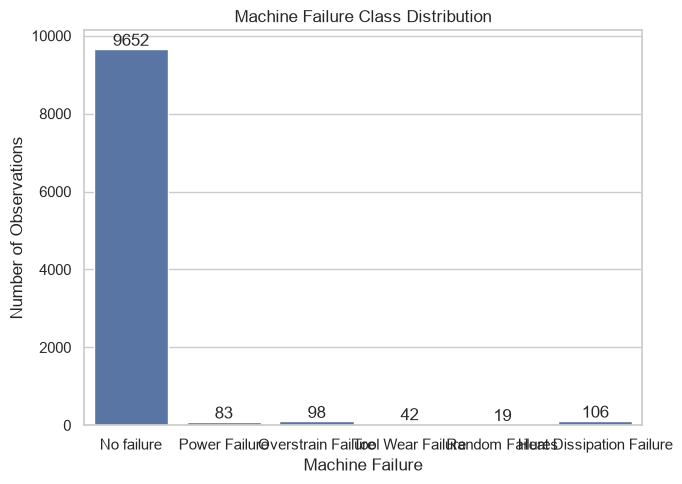

In [10]:
# Target distribution plot

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=classification_df,
    x=target
)

plt.title("Machine Failure Class Distribution")
plt.xlabel("Machine Failure")
plt.ylabel("Number of Observations")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Target Distribution Observation

The classes are severely imbalanced: `No failure` accounts for 96.52% of observations (9,652 of 10,000), while the five failure types together make up only 3.48% — Heat Dissipation Failure (1.06%), Overstrain Failure (0.98%), Power Failure (0.83%), Tool Wear Failure (0.42%), and Random Failures (0.19%). The two rarest classes have fewer than 50 examples in the entire dataset, so they are likely to be the hardest for any model to learn.

## 6. Feature Engineering

A temperature-difference feature is created to represent the gap between process temperature and air temperature. This may give the models a direct signal for the machine's thermal state.

In [11]:
# Feature engineering

classification_df["Temperature Difference (K)"] = (
    classification_df["Process temperature (K)"]
    - classification_df["Air temperature (K)"]
)

print("Engineered feature created successfully.")

display(
    classification_df[
        [
            "Air temperature (K)",
            "Process temperature (K)",
            "Temperature Difference (K)"
        ]
    ].head()
)

Engineered feature created successfully.


,Air temperature (K),Process temperature (K),Temperature Difference (K)
0,NaN,NaN,NaN
1,298.2,308.7,10.5
2,298.1,308.5,10.4
3,NaN,NaN,NaN
4,NaN,NaN,NaN


## 7. Feature Distribution Analysis

The distributions of the numerical features are visualized to understand their shape, spread, skewness, and potential unusual observations.

In [12]:
# Numerical features for EDA

numerical_eda_features = [
    "Air temperature (K)",
    "Process temperature (K)",
    "Rotational speed (rpm)",
    "Torque (Nm)",
    "Tool wear (min)"
]

print("Numerical EDA features:")
print(numerical_eda_features)

Numerical EDA features:
['Air temperature (K)', 'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)', 'Tool wear (min)']


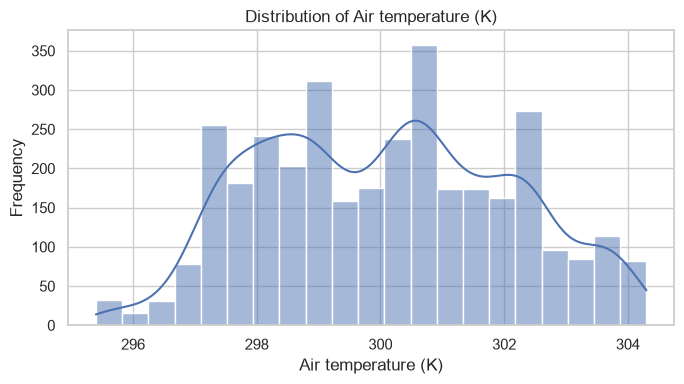

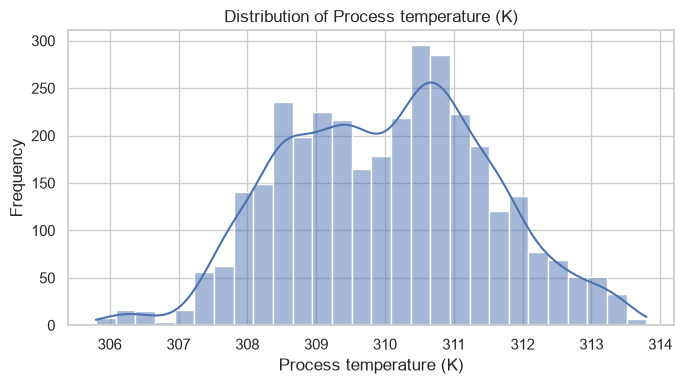

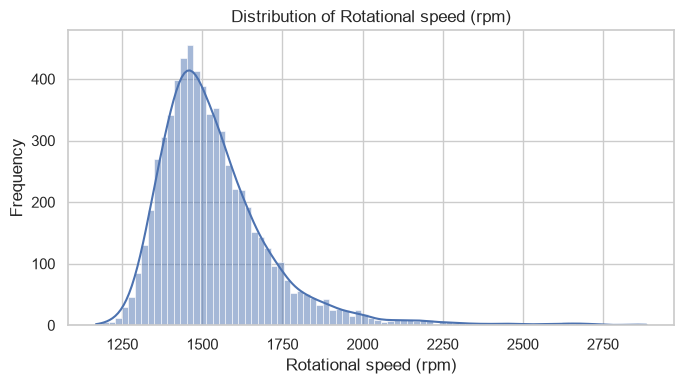

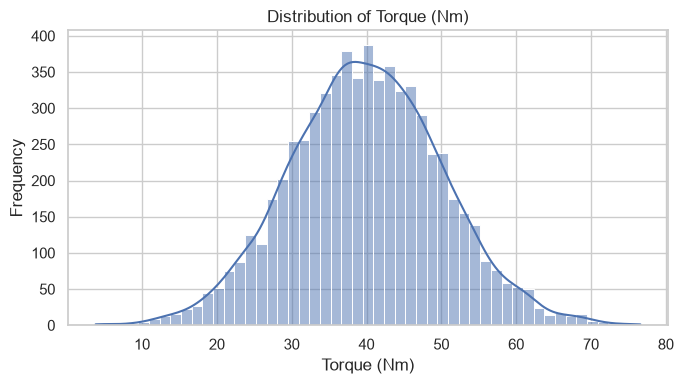

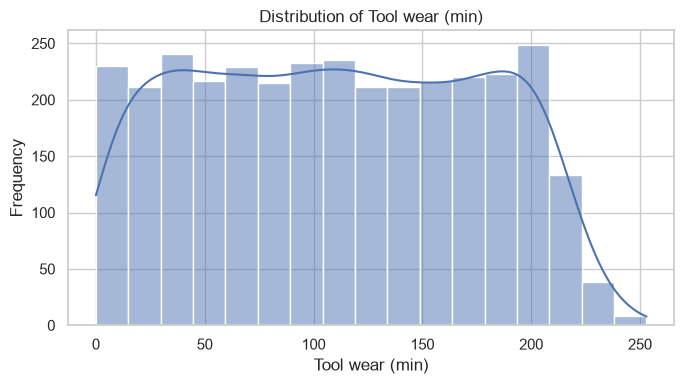

In [13]:
# Distribution plots for numerical features

for feature in numerical_eda_features:
    plt.figure(figsize=(7, 4))

    sns.histplot(
        data=classification_df,
        x=feature,
        kde=True
    )

    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

### Distribution Plot Observation

The temperature-related variables occupy relatively narrow ranges, while rotational speed, torque, and tool wear show much greater spread. These distributions are examined further in the outlier analysis below.

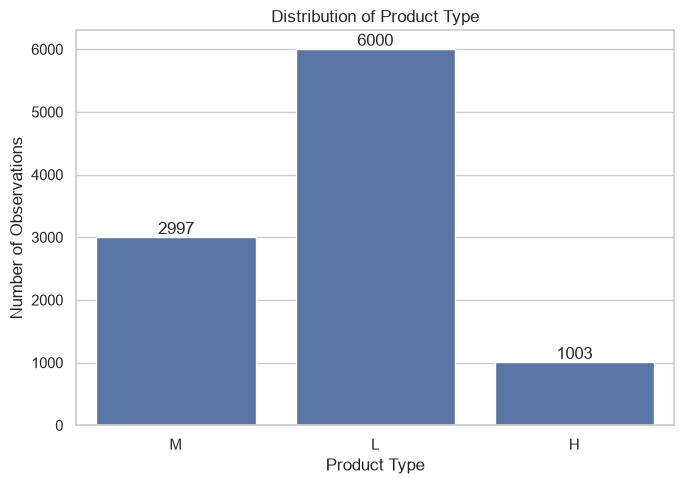

In [14]:
# Distribution plot for categorical feature

plt.figure(figsize=(7, 5))

ax = sns.countplot(
    data=classification_df,
    x="Type"
)

plt.title("Distribution of Product Type")
plt.xlabel("Product Type")
plt.ylabel("Number of Observations")

for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.show()

### Product Type Observation

Observations are spread unevenly across the three product types. `Type` will be one-hot encoded so it can be used by the classification algorithms.

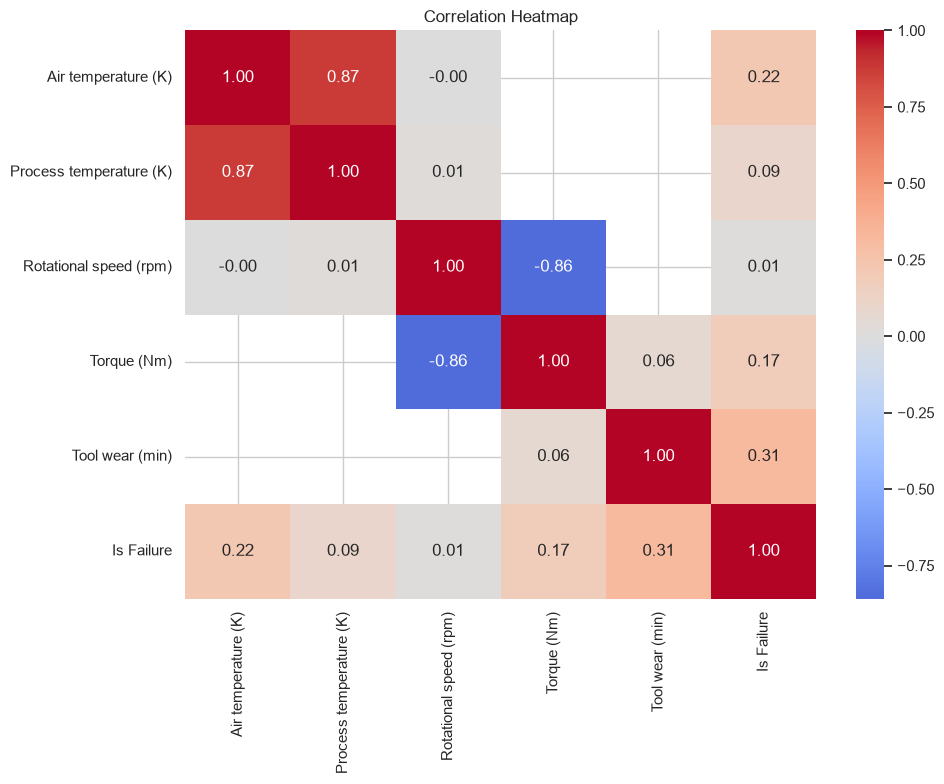

In [15]:
# Correlation heatmap

# Diagnostic has 6 unordered categories, so encoding it with arbitrary
# integer codes and computing Pearson correlation against it would not
# be meaningful. A binary indicator (any failure vs. no failure) is
# used instead, since that is an actual 0/1 quantity.

correlation_df = classification_df[numerical_eda_features].copy()
correlation_df["Is Failure"] = (
    classification_df[target] != "No failure"
).astype(int)

correlation_matrix = correlation_df.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

## 8. Feature–Target Relationship Analysis

The correlation heatmap above and the plots below compare machine operating characteristics across the six Diagnostic classes, to see whether any of them visibly separate normal operation from a specific failure type.

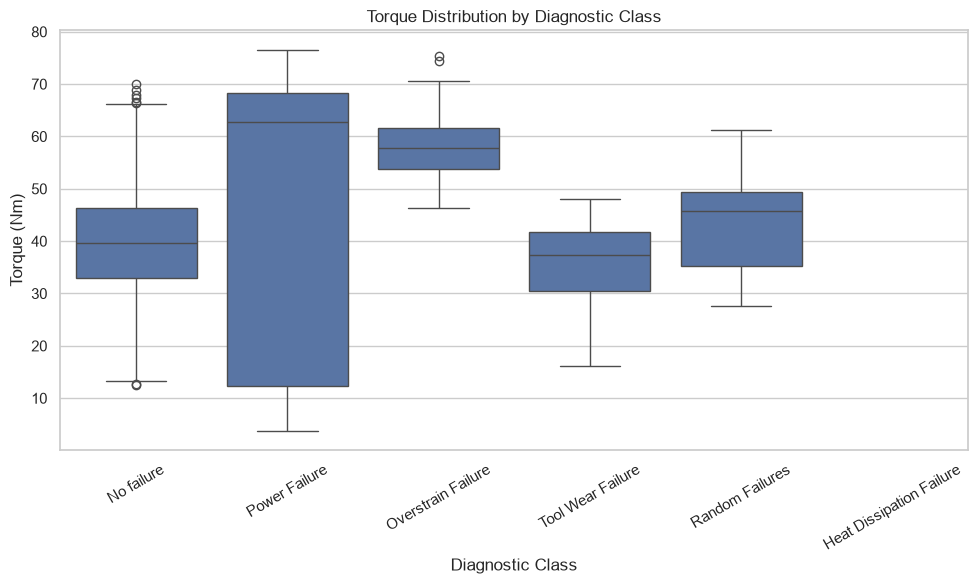

In [16]:
# Torque vs Diagnostic Class

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=classification_df,
    x=target,
    y="Torque (Nm)"
)

plt.title("Torque Distribution by Diagnostic Class")
plt.xlabel("Diagnostic Class")
plt.ylabel("Torque (Nm)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

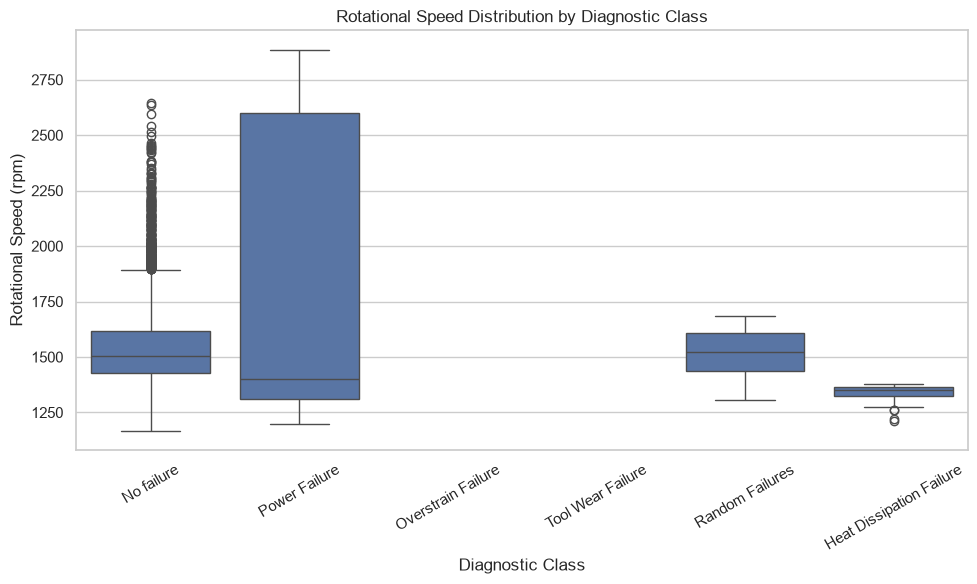

In [17]:
# Rotational Speed vs Diagnostic Class

plt.figure(figsize=(10, 6))

sns.boxplot(
    data=classification_df,
    x=target,
    y="Rotational speed (rpm)"
)

plt.title("Rotational Speed Distribution by Diagnostic Class")
plt.xlabel("Diagnostic Class")
plt.ylabel("Rotational Speed (rpm)")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 9. Outlier Analysis

Outliers are examined using the IQR method. For each numerical feature:

- Q1 = 25th percentile, Q3 = 75th percentile
- IQR = Q3 − Q1
- Lower bound = Q1 − 1.5 × IQR, Upper bound = Q3 + 1.5 × IQR

The number of observations outside these bounds is reported for each feature.

In [18]:
# IQR-based outlier analysis

outlier_summary = []

for feature in numerical_eda_features:
    Q1 = classification_df[feature].quantile(0.25)
    Q3 = classification_df[feature].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = classification_df[
        (classification_df[feature] < lower_bound) |
        (classification_df[feature] > upper_bound)
    ]

    outlier_summary.append({
        "Feature": feature,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "Lower Bound": lower_bound,
        "Upper Bound": upper_bound,
        "Outlier Count": len(outliers),
        "Outlier Percentage": len(outliers) / len(classification_df) * 100
    })

outlier_summary_df = pd.DataFrame(outlier_summary)

outlier_summary_df["Outlier Percentage"] = (
    outlier_summary_df["Outlier Percentage"].round(2)
)

display(outlier_summary_df)

,Feature,Q1,Q3,IQR,Lower Bound,Upper Bound,Outlier Count,Outlier Percentage
0,Air temperature (K),298.4,301.6,3.2,293.60,306.40,0,0.00
1,Process temperature (K),308.9,311.1,2.2,305.60,314.40,0,0.00
2,Rotational speed (rpm),1423.0,1613.5,190.5,1137.25,1899.25,286,2.86
3,Torque (Nm),33.1,46.7,13.6,12.70,67.10,64,0.64
4,Tool wear (min),55.0,167.0,112.0,-113.00,335.00,0,0.00


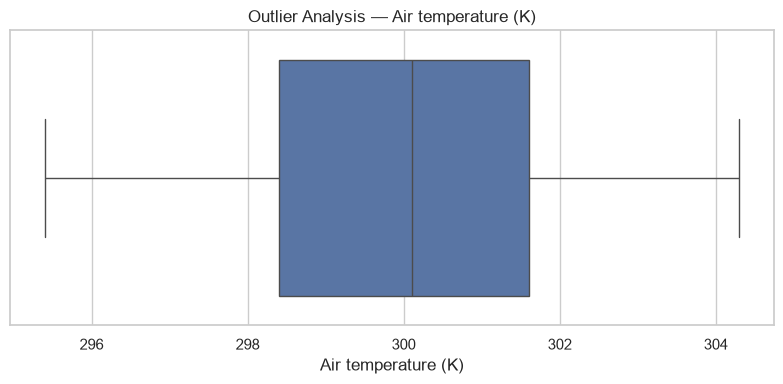

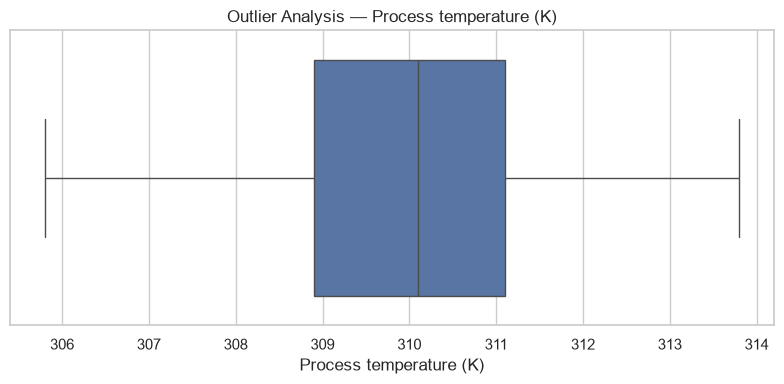

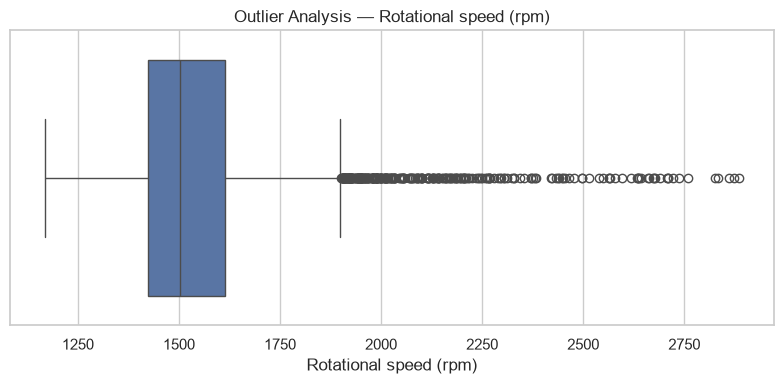

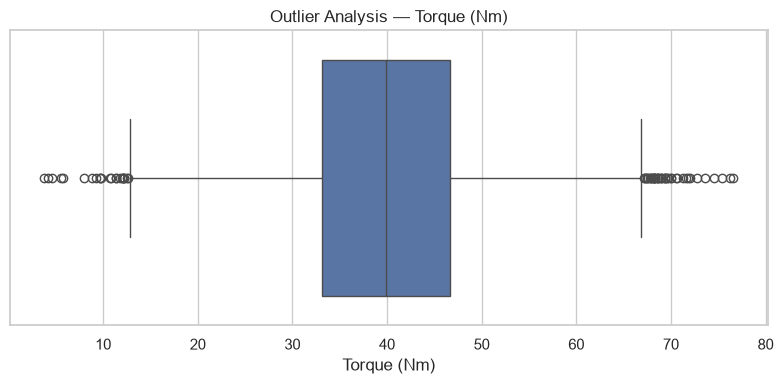

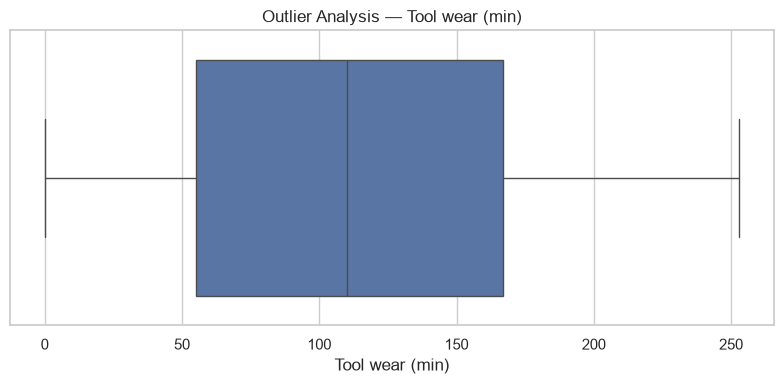

In [19]:
# Boxplots for numerical features

for feature in numerical_eda_features:
    plt.figure(figsize=(8, 4))

    sns.boxplot(
        data=classification_df,
        x=feature
    )

    plt.title(f"Outlier Analysis — {feature}")
    plt.xlabel(feature)

    plt.tight_layout()
    plt.show()

## 10. Define Predictors and Target

Identifier columns (`UDI`, `Date`, `System`, `Control`, `Product ID`) and the target column (`Diagnostic`) are excluded from the predictor matrix. No separate failure-mode indicator columns exist in this dataset, so there is nothing further to drop for leakage.

In [20]:
# Define predictors and target

columns_to_drop = [
    "UDI",
    "Date",
    "System",
    "Control",
    "Product ID",
    "Diagnostic"
]

X = classification_df.drop(columns=columns_to_drop)
y = classification_df[target]

print("Predictor columns:")
print(X.columns.tolist())

print("\nPredictor shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget classes:")
print(y.unique())

Predictor columns:
['Type', 'Air temperature (K)', 'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)', 'Tool wear (min)', 'Temperature Difference (K)']

Predictor shape: (10000, 7)
Target shape: (10000,)

Target classes:
<StringArray>
[              'No failure',            'Power Failure',
       'Overstrain Failure',        'Tool Wear Failure',
          'Random Failures', 'Heat Dissipation Failure']
Length: 6, dtype: str


## 11. Stratified Train-Test Split

The dataset is split 80:20 into training and testing sets. Stratification preserves the proportion of each Diagnostic class in both subsets, which matters given how rare some failure types are. The test set is not used to fit any preprocessing transformations or models.

In [21]:
# Stratified train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

print("\nTraining target distribution:")
display(y_train.value_counts())

print("\nTest target distribution:")
display(y_test.value_counts())

Training set shape: (8000, 7)
Test set shape: (2000, 7)

Training target distribution:


Diagnostic
No failure                  7722
Heat Dissipation Failure      85
Overstrain Failure            78
Power Failure                 66
Tool Wear Failure             34
Random Failures               15
Name: count, dtype: int64


Test target distribution:


Diagnostic
No failure                  1930
Heat Dissipation Failure      21
Overstrain Failure            20
Power Failure                 17
Tool Wear Failure              8
Random Failures                4
Name: count, dtype: int64

### Split Observation

The stratified split keeps a similar proportion of each Diagnostic class in both the training and testing sets, which is important given how imbalanced the classes are.

## 12. Leakage-Safe Preprocessing Pipeline

Numerical features are median-imputed and standardized with `StandardScaler`. The categorical `Type` feature is imputed with its most frequent value and one-hot encoded. All steps sit inside a `ColumnTransformer`, itself inside each model's `Pipeline`, so preprocessing parameters are learned only from the training data.

In [22]:
# Identify numerical and categorical features

numerical_features = [
    "Air temperature (K)",
    "Process temperature (K)",
    "Rotational speed (rpm)",
    "Torque (Nm)",
    "Tool wear (min)"
]

categorical_features = [
    "Type"
]

print("Numerical features:")
print(numerical_features)

print("\nCategorical features:")
print(categorical_features)

Numerical features:
['Air temperature (K)', 'Process temperature (K)', 'Rotational speed (rpm)', 'Torque (Nm)', 'Tool wear (min)']

Categorical features:
['Type']


In [23]:
# Build leakage-safe preprocessing pipeline

numerical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore"))
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numerical_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

print("Preprocessing pipeline created successfully.")

Preprocessing pipeline created successfully.


## 13. Classification Models — Part A

Five classification algorithms required for Review 1 Part A are trained on the same train/test split and preprocessing pipeline:

1. Logistic Regression
2. K-Nearest Neighbors
3. Gaussian Naive Bayes
4. Decision Tree Classifier
5. Support Vector Classifier

In [24]:
# Define Part A classification models

models = {
    "Logistic Regression": LogisticRegression(
        random_state=RANDOM_STATE,
        max_iter=1000
    ),

    "KNN Classifier": KNeighborsClassifier(
        n_neighbors=5
    ),

    "Gaussian Naive Bayes": GaussianNB(),

    "Decision Tree Classifier": DecisionTreeClassifier(
        random_state=RANDOM_STATE
    ),

    "SVC": SVC(
        random_state=RANDOM_STATE,
        probability=True
    )
}

print("Five Part A models defined successfully.")

Five Part A models defined successfully.


## 14. Train and Evaluate Part A Models

Each classifier sits inside a `Pipeline` with the shared preprocessing steps, so every model receives consistently processed data with no leakage.

## 14.1 Logistic Regression

Logistic Regression is used as the baseline classifier for predicting the Diagnostic class. It estimates class probabilities and assigns each observation to the class with the highest predicted probability.

Logistic Regression
----------------------------------------
Accuracy : 0.9770
Precision: 0.9670
Recall   : 0.9770
F1-Score : 0.9719
ROC-AUC  : 0.9649

Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.70      0.76      0.73        21
              No failure       0.98      0.99      0.99      1930
      Overstrain Failure       1.00      1.00      1.00        20
           Power Failure       0.00      0.00      0.00        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.25      0.12      0.17         8

                accuracy                           0.98      2000
               macro avg       0.49      0.48      0.48      2000
            weighted avg       0.97      0.98      0.97      2000



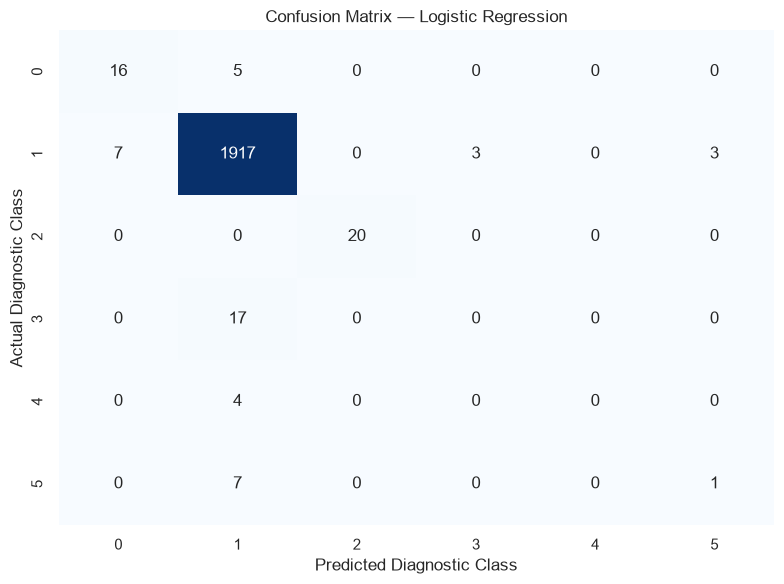

In [25]:
# Logistic Regression

logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", LogisticRegression(
            random_state=RANDOM_STATE,
            max_iter=1000
        ))
    ]
)

# Train the model
logistic_pipeline.fit(X_train, y_train)

# Predictions
logistic_predictions = logistic_pipeline.predict(X_test)
logistic_probabilities = logistic_pipeline.predict_proba(X_test)

# Evaluation metrics
logistic_accuracy = accuracy_score(
    y_test,
    logistic_predictions
)

logistic_precision = precision_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_recall = recall_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

logistic_f1 = f1_score(
    y_test,
    logistic_predictions,
    average="weighted",
    zero_division=0
)

# Multiclass ROC-AUC using One-vs-Rest
logistic_roc_auc = roc_auc_score(
    y_test,
    logistic_probabilities,
    multi_class="ovr",
    average="weighted"
)

# Confusion matrix
logistic_cm = confusion_matrix(
    y_test,
    logistic_predictions
)

print("Logistic Regression")
print("-" * 40)
print(f"Accuracy : {logistic_accuracy:.4f}")
print(f"Precision: {logistic_precision:.4f}")
print(f"Recall   : {logistic_recall:.4f}")
print(f"F1-Score : {logistic_f1:.4f}")
print(f"ROC-AUC  : {logistic_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        zero_division=0
    )
)

# Confusion matrix
plt.figure(figsize=(8, 6))

sns.heatmap(
    logistic_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix — Logistic Regression")
plt.xlabel("Predicted Diagnostic Class")
plt.ylabel("Actual Diagnostic Class")

plt.tight_layout()
plt.show()

## 14.2 K-Nearest Neighbors (KNN)

KNN classifies an observation from the classes of its nearest neighbors. Because it relies on distances between points, feature scaling matters — the preprocessing pipeline standardizes the numerical features before classification.

K-Nearest Neighbors
----------------------------------------
Accuracy : 0.9885
Precision: 0.9827
Recall   : 0.9885
F1-Score : 0.9855
ROC-AUC  : 0.9533

Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.83      0.95      0.89        21
              No failure       0.99      1.00      0.99      1930
      Overstrain Failure       1.00      1.00      1.00        20
           Power Failure       0.87      0.76      0.81        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         8

                accuracy                           0.99      2000
               macro avg       0.62      0.62      0.62      2000
            weighted avg       0.98      0.99      0.99      2000



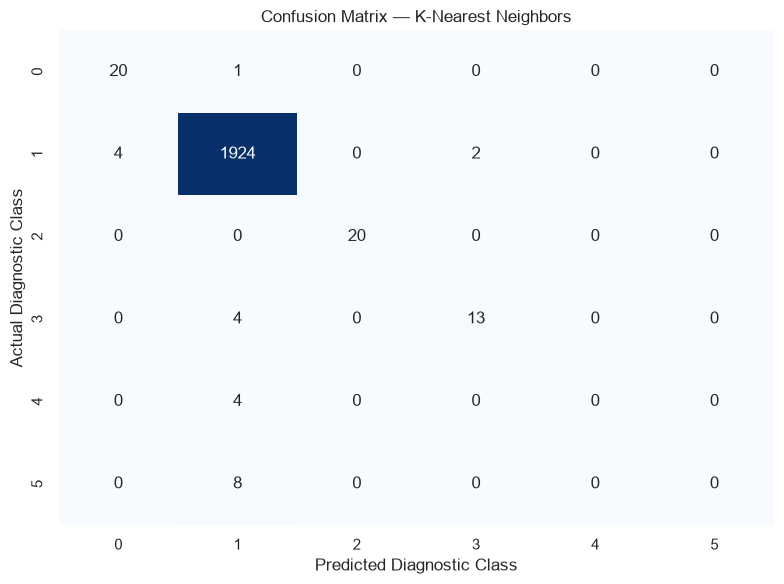

In [26]:
# K-Nearest Neighbors

knn_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", KNeighborsClassifier(
            n_neighbors=5
        ))
    ]
)

# Train the model
knn_pipeline.fit(X_train, y_train)

# Predictions
knn_predictions = knn_pipeline.predict(X_test)

# Full probability matrix for multiclass ROC-AUC
knn_probabilities = knn_pipeline.predict_proba(X_test)

# Evaluation metrics
knn_accuracy = accuracy_score(
    y_test,
    knn_predictions
)

knn_precision = precision_score(
    y_test,
    knn_predictions,
    average="weighted",
    zero_division=0
)

knn_recall = recall_score(
    y_test,
    knn_predictions,
    average="weighted",
    zero_division=0
)

knn_f1 = f1_score(
    y_test,
    knn_predictions,
    average="weighted",
    zero_division=0
)

# Multiclass ROC-AUC using One-vs-Rest
knn_roc_auc = roc_auc_score(
    y_test,
    knn_probabilities,
    multi_class="ovr",
    average="weighted"
)

# Confusion matrix
knn_cm = confusion_matrix(
    y_test,
    knn_predictions
)

print("K-Nearest Neighbors")
print("-" * 40)
print(f"Accuracy : {knn_accuracy:.4f}")
print(f"Precision: {knn_precision:.4f}")
print(f"Recall   : {knn_recall:.4f}")
print(f"F1-Score : {knn_f1:.4f}")
print(f"ROC-AUC  : {knn_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        knn_predictions,
        zero_division=0
    )
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    knn_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix — K-Nearest Neighbors")
plt.xlabel("Predicted Diagnostic Class")
plt.ylabel("Actual Diagnostic Class")

plt.tight_layout()
plt.show()

## 14.3 Gaussian Naive Bayes

Gaussian Naive Bayes is a probabilistic classifier that assumes features are conditionally independent given the class. It is fast to train and gives a useful probabilistic baseline for this diagnostic classification problem.

Gaussian Naive Bayes
----------------------------------------
Accuracy : 0.4155
Precision: 0.9648
Recall   : 0.4155
F1-Score : 0.5523
ROC-AUC  : 0.8476

Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.09      1.00      0.16        21
              No failure       1.00      0.40      0.57      1930
      Overstrain Failure       0.10      1.00      0.18        20
           Power Failure       0.03      1.00      0.05        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.05      0.88      0.10         8

                accuracy                           0.42      2000
               macro avg       0.21      0.71      0.18      2000
            weighted avg       0.96      0.42      0.55      2000



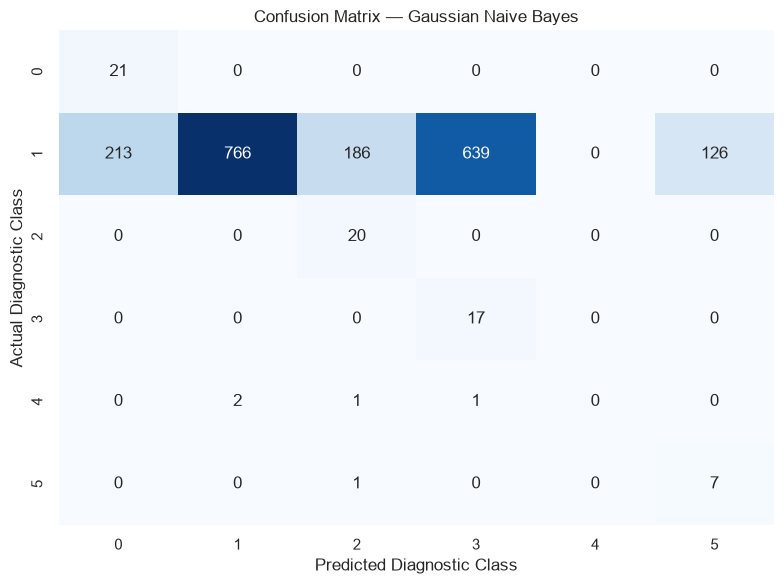

In [27]:
# Gaussian Naive Bayes

gnb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", GaussianNB())
    ]
)

# Train the model
gnb_pipeline.fit(X_train, y_train)

# Predictions
gnb_predictions = gnb_pipeline.predict(X_test)

# Full probability matrix for multiclass ROC-AUC
gnb_probabilities = gnb_pipeline.predict_proba(X_test)

# Evaluation metrics
gnb_accuracy = accuracy_score(
    y_test,
    gnb_predictions
)

gnb_precision = precision_score(
    y_test,
    gnb_predictions,
    average="weighted",
    zero_division=0
)

gnb_recall = recall_score(
    y_test,
    gnb_predictions,
    average="weighted",
    zero_division=0
)

gnb_f1 = f1_score(
    y_test,
    gnb_predictions,
    average="weighted",
    zero_division=0
)

# Multiclass ROC-AUC using One-vs-Rest
gnb_roc_auc = roc_auc_score(
    y_test,
    gnb_probabilities,
    multi_class="ovr",
    average="weighted"
)

# Confusion matrix
gnb_cm = confusion_matrix(
    y_test,
    gnb_predictions
)

print("Gaussian Naive Bayes")
print("-" * 40)
print(f"Accuracy : {gnb_accuracy:.4f}")
print(f"Precision: {gnb_precision:.4f}")
print(f"Recall   : {gnb_recall:.4f}")
print(f"F1-Score : {gnb_f1:.4f}")
print(f"ROC-AUC  : {gnb_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        gnb_predictions,
        zero_division=0
    )
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    gnb_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix — Gaussian Naive Bayes")
plt.xlabel("Predicted Diagnostic Class")
plt.ylabel("Actual Diagnostic Class")

plt.tight_layout()
plt.show()

## 14.4 Decision Tree Classifier

Decision Tree Classifier predicts the Diagnostic class by recursively splitting the data on feature values. Its decisions can be read as a sequence of interpretable rules.

Decision Tree Classifier
----------------------------------------
Accuracy : 0.9870
Precision: 0.9861
Recall   : 0.9870
F1-Score : 0.9865
ROC-AUC  : 0.8901

Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure       1.00      0.86      0.92        21
              No failure       0.99      0.99      0.99      1930
      Overstrain Failure       1.00      1.00      1.00        20
           Power Failure       0.89      0.94      0.91        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.14      0.12      0.13         8

                accuracy                           0.99      2000
               macro avg       0.67      0.65      0.66      2000
            weighted avg       0.99      0.99      0.99      2000



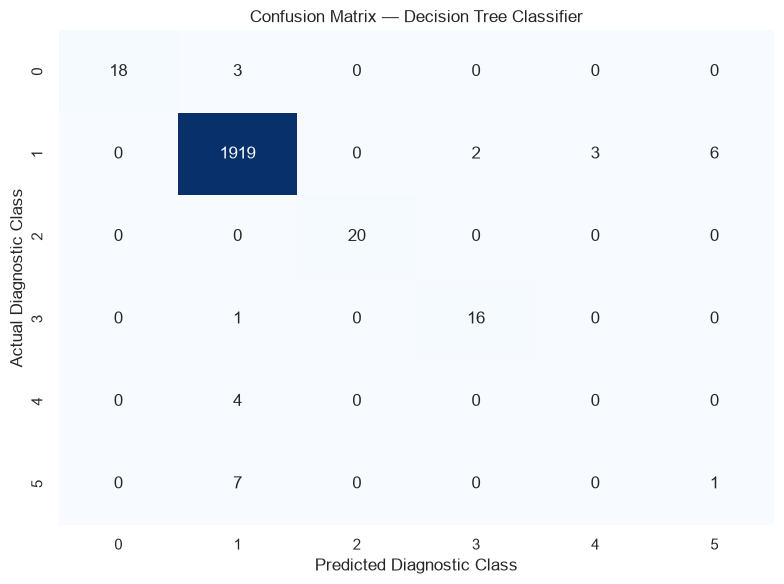

In [28]:
# Decision Tree Classifier

decision_tree_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DecisionTreeClassifier(
            random_state=RANDOM_STATE
        ))
    ]
)

# Train the model
decision_tree_pipeline.fit(X_train, y_train)

# Predictions
decision_tree_predictions = decision_tree_pipeline.predict(X_test)

# Full probability matrix for multiclass ROC-AUC
decision_tree_probabilities = (
    decision_tree_pipeline.predict_proba(X_test)
)

# Evaluation metrics
decision_tree_accuracy = accuracy_score(
    y_test,
    decision_tree_predictions
)

decision_tree_precision = precision_score(
    y_test,
    decision_tree_predictions,
    average="weighted",
    zero_division=0
)

decision_tree_recall = recall_score(
    y_test,
    decision_tree_predictions,
    average="weighted",
    zero_division=0
)

decision_tree_f1 = f1_score(
    y_test,
    decision_tree_predictions,
    average="weighted",
    zero_division=0
)

# Multiclass ROC-AUC using One-vs-Rest
decision_tree_roc_auc = roc_auc_score(
    y_test,
    decision_tree_probabilities,
    multi_class="ovr",
    average="weighted"
)

# Confusion matrix
decision_tree_cm = confusion_matrix(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Classifier")
print("-" * 40)
print(f"Accuracy : {decision_tree_accuracy:.4f}")
print(f"Precision: {decision_tree_precision:.4f}")
print(f"Recall   : {decision_tree_recall:.4f}")
print(f"F1-Score : {decision_tree_f1:.4f}")
print(f"ROC-AUC  : {decision_tree_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        decision_tree_predictions,
        zero_division=0
    )
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    decision_tree_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix — Decision Tree Classifier")
plt.xlabel("Predicted Diagnostic Class")
plt.ylabel("Actual Diagnostic Class")

plt.tight_layout()
plt.show()

## 14.5 Support Vector Classifier (SVC)

SVC finds a decision boundary that separates the classes while maximizing the margin between them. It is sensitive to feature scale, so it relies on the same standardized features from the preprocessing pipeline.

C:\Users\rsrib\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Support Vector Classifier
----------------------------------------
Accuracy : 0.9865
Precision: 0.9805
Recall   : 0.9865
F1-Score : 0.9833
ROC-AUC  : 0.9572

Classification Report:
                          precision    recall  f1-score   support

Heat Dissipation Failure       0.75      0.71      0.73        21
              No failure       0.99      1.00      0.99      1930
      Overstrain Failure       1.00      1.00      1.00        20
           Power Failure       1.00      0.76      0.87        17
         Random Failures       0.00      0.00      0.00         4
       Tool Wear Failure       0.00      0.00      0.00         8

                accuracy                           0.99      2000
               macro avg       0.62      0.58      0.60      2000
            weighted avg       0.98      0.99      0.98      2000



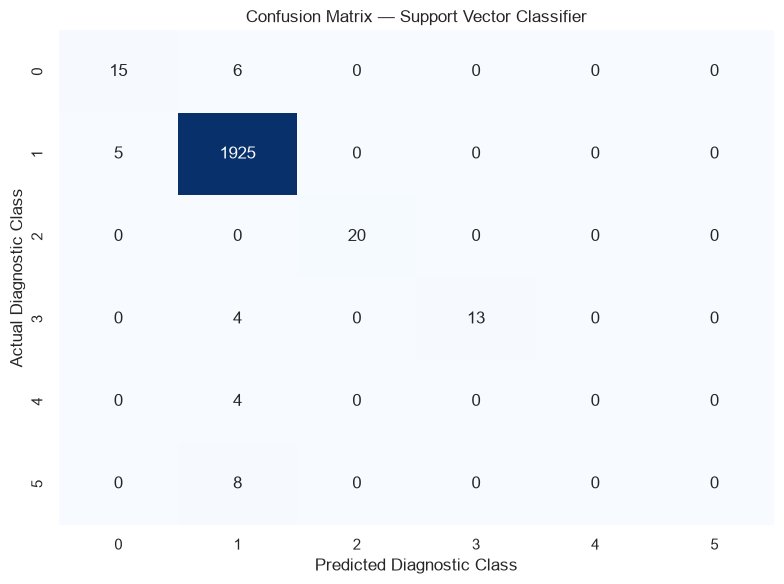

In [29]:
# Support Vector Classifier

svc_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", SVC(
            random_state=RANDOM_STATE,
            probability=True
        ))
    ]
)

# Train the model
svc_pipeline.fit(X_train, y_train)

# Predictions
svc_predictions = svc_pipeline.predict(X_test)

# Full probability matrix for multiclass ROC-AUC
svc_probabilities = svc_pipeline.predict_proba(X_test)

# Evaluation metrics
svc_accuracy = accuracy_score(
    y_test,
    svc_predictions
)

svc_precision = precision_score(
    y_test,
    svc_predictions,
    average="weighted",
    zero_division=0
)

svc_recall = recall_score(
    y_test,
    svc_predictions,
    average="weighted",
    zero_division=0
)

svc_f1 = f1_score(
    y_test,
    svc_predictions,
    average="weighted",
    zero_division=0
)

# Multiclass ROC-AUC using One-vs-Rest
svc_roc_auc = roc_auc_score(
    y_test,
    svc_probabilities,
    multi_class="ovr",
    average="weighted"
)

# Confusion matrix
svc_cm = confusion_matrix(
    y_test,
    svc_predictions
)

print("Support Vector Classifier")
print("-" * 40)
print(f"Accuracy : {svc_accuracy:.4f}")
print(f"Precision: {svc_precision:.4f}")
print(f"Recall   : {svc_recall:.4f}")
print(f"F1-Score : {svc_f1:.4f}")
print(f"ROC-AUC  : {svc_roc_auc:.4f}")

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        svc_predictions,
        zero_division=0
    )
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    svc_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix — Support Vector Classifier")
plt.xlabel("Predicted Diagnostic Class")
plt.ylabel("Actual Diagnostic Class")

plt.tight_layout()
plt.show()

In [30]:
# Part A classification comparison

classification_results_df = pd.DataFrame([
    {
        "Model": "Logistic Regression",
        "Accuracy": logistic_accuracy,
        "Precision": logistic_precision,
        "Recall": logistic_recall,
        "F1-Score": logistic_f1,
        "ROC-AUC": logistic_roc_auc
    },
    {
        "Model": "KNN Classifier",
        "Accuracy": knn_accuracy,
        "Precision": knn_precision,
        "Recall": knn_recall,
        "F1-Score": knn_f1,
        "ROC-AUC": knn_roc_auc
    },
    {
        "Model": "Gaussian Naive Bayes",
        "Accuracy": gnb_accuracy,
        "Precision": gnb_precision,
        "Recall": gnb_recall,
        "F1-Score": gnb_f1,
        "ROC-AUC": gnb_roc_auc
    },
    {
        "Model": "Decision Tree Classifier",
        "Accuracy": decision_tree_accuracy,
        "Precision": decision_tree_precision,
        "Recall": decision_tree_recall,
        "F1-Score": decision_tree_f1,
        "ROC-AUC": decision_tree_roc_auc
    },
    {
        "Model": "SVC",
        "Accuracy": svc_accuracy,
        "Precision": svc_precision,
        "Recall": svc_recall,
        "F1-Score": svc_f1,
        "ROC-AUC": svc_roc_auc
    }
])

classification_results_df = (
    classification_results_df
    .sort_values(by="F1-Score", ascending=False)
    .reset_index(drop=True)
)

classification_results_df.insert(
    0,
    "Rank",
    range(1, len(classification_results_df) + 1)
)

display(
    classification_results_df.round(4)
)

,Rank,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,Decision Tree Classifier,0.9870,0.9861,0.9870,0.9865,0.8901
1,2,KNN Classifier,0.9885,0.9827,0.9885,0.9855,0.9533
2,3,SVC,0.9865,0.9805,0.9865,0.9833,0.9572
3,4,Logistic Regression,0.9770,0.9670,0.9770,0.9719,0.9649
4,5,Gaussian Naive Bayes,0.4155,0.9648,0.4155,0.5523,0.8476


## 15. Best Part A Model Selection

Models are ranked by weighted F1-score, since the classes are heavily imbalanced. By this measure, **Decision Tree Classifier** performs best (F1 = 0.9865, Accuracy = 0.9870), followed closely by KNN (F1 = 0.9855) and SVC (F1 = 0.9833).

However, weighted F1 is dominated by the large `No failure` class — all five models struggle on the rarest classes: `Random Failures` (19 samples) gets 0% recall from every model, and `Tool Wear Failure` is also poorly identified by most. This is worth calling out explicitly in the viva, since high weighted-average scores can mask near-total failure to detect the rarest failure types.

In [31]:
# Select the best Part A model

best_model_name = classification_results_df.iloc[0]["Model"]

best_model_mapping = {
    "Logistic Regression": logistic_pipeline,
    "KNN Classifier": knn_pipeline,
    "Gaussian Naive Bayes": gnb_pipeline,
    "Decision Tree Classifier": decision_tree_pipeline,
    "SVC": svc_pipeline
}

best_model = best_model_mapping[best_model_name]

print("Best Part A Model:", best_model_name)

display(
    classification_results_df[
        classification_results_df["Model"] == best_model_name
    ].round(4)
)

Best Part A Model: Decision Tree Classifier


,Rank,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC
0,1,Decision Tree Classifier,0.987,0.9861,0.987,0.9865,0.8901
